In [31]:
import os
import json
import textwrap
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def list_subdirectories(flux_dir):
    return [
        name for name in os.listdir(flux_dir)
        if os.path.isdir(os.path.join(flux_dir, name)) and 'logs' not in name
    ]


In [32]:

filtered_flux_results_path = '/data3/jhpark/filtered_artifacts_100'
filtered_flux_results_dirs = list_subdirectories(filtered_flux_results_path)

In [63]:
def plot_explanations(parent_dir, subdirectory):
    metadata_path = os.path.join(parent_dir, subdirectory, "metadata.json")
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    artifact_image_path = os.path.join(parent_dir, subdirectory, "artifact_image.png")
    img = mpimg.imread(artifact_image_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')

    for idx, artifact in enumerate(metadata):
        bbox = artifact['target_bbox']
        x1, y1, x2, y2 = bbox
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)
        plt.gca().text(x1, y1 - 5, str(idx) +' ' + artifact['artifact_type'], color='white', fontsize=12, weight='bold', va='bottom', ha='left', bbox=dict(facecolor='r', alpha=0.5, edgecolor='none', pad=1))
        print('\n'.join(textwrap.wrap(artifact['explanation'], width=80)))
        print('--------------------------------')
    plt.show()
        


In [64]:
flux_results_iter = iter(filtered_flux_results_dirs)

In the highlighted region, there appears to be an extra ear that is not
naturally aligned with the rest of the cat's anatomy. This additional ear seems
out of place and creates an unnatural appearance, as cats typically have only
two ears symmetrically positioned on their heads. The presence of this extra
element disrupts the normal structure and balance of the cat's features.
--------------------------------
In the highlighted region, the tail appears unusually thick and elongated, with
an unnatural bend that doesn't align with typical feline anatomy. The texture
and shading seem inconsistent with the rest of the body, suggesting an abnormal
growth or duplication.
--------------------------------
In the highlighted region, there appears to be an extra ear on the cat. This
additional ear looks unnatural as cats typically have only two ears,
symmetrically placed on their heads. The presence of this third ear disrupts the
normal anatomy and symmetry expected in a cat's appearance.
------

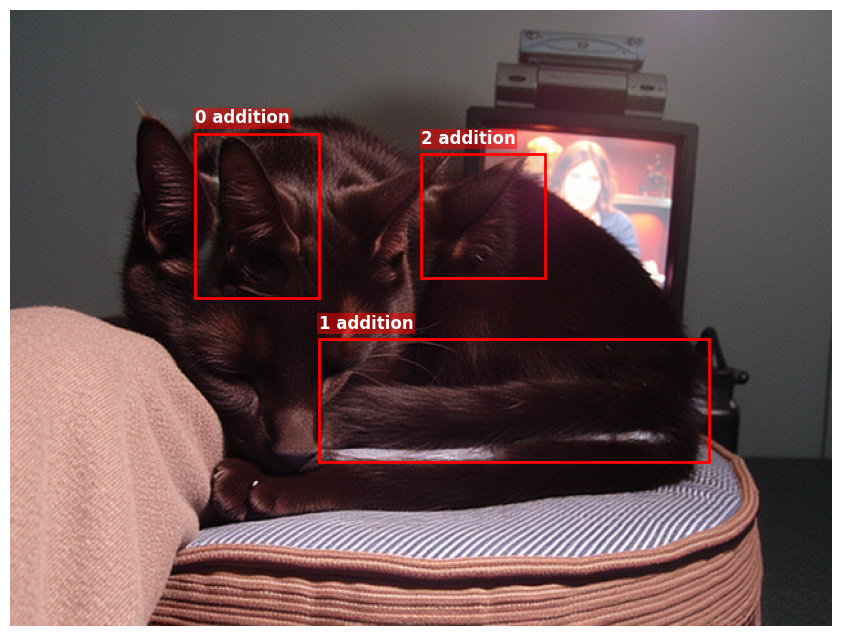

In [65]:
flux_result = next(flux_results_iter)
plot_explanations(filtered_flux_results_path, flux_result)